In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
# Directories to load
data_dirs_math = [
    Path("../") / "generated_math"
    #Path("../data") / "generated_math_2",

    #Path("../data") / "generated2",
]
# data_dir_aime =[Path("..") / "generated_aime_dataset"]

# Collect CSVs from all directories
csv_files_math = []
# csv_files_aime = []
for d in data_dirs_math:
    csv_files_math.extend([f for f in d.iterdir() if f.suffix == ".csv"])
    
# for d in data_dir_aime:
#     csv_files_aime.extend([f for f in d.iterdir() if f.suffix == ".csv"])


df_math = pd.concat((pd.read_csv(f) for f in csv_files_math), ignore_index=True)
# df_aime = pd.concat((pd.read_csv(f) for f in csv_files_aime), ignore_index=True)

In [26]:
df_generated = pd.read_parquet("results_full1.parquet")
df_math = df_generated
df_math.shape

(125000, 9)

In [27]:
df_part = df_math.iloc[::100, :].copy()  # Use a subset for faster plotting
df_part.to_csv("df_part.csv", index=False)

In [22]:
df_part.shape

(1250, 9)

In [7]:
print(f"Unique questions: {df_math['question_id'].nunique()}")
print(f"Minimum questionId:{df_math['question_id'].unique().min()} Max questionId: {df_math['question_id'].unique().max()}")
num = df_math.loc[df_math["is_correct"], "question_id"].nunique()
print(f"Correct: {num}")
print(f"Overall accuracy: {df_math['is_correct'].mean() * 100:.2f}%")


Unique questions: 12500
Minimum questionId:0 Max questionId: 12499
Correct: 11358
Overall accuracy: 75.67%


In [43]:
print(f"Loaded {len(csv_files_aime)} CSV files")
print(f"Unique questions: {df_aime['question_id'].nunique()}")
print(f"Minimum questionId:{df_aime['question_id'].unique().min()} Max questionId: {df_aime['question_id'].unique().max()}")
num = df_aime.loc[df_aime["is_correct"], "question_id"].nunique()
print(f"Correct: {num}")
print(f"Overall accuracy: {df_aime['is_correct'].mean() * 100:.2f}%")

Loaded 103 CSV files
Unique questions: 660
Minimum questionId:1983-1 Max questionId: 2015-I-9
Correct: 373
Overall accuracy: 29.51%


In [8]:

tokens = np.linspace(100, 2500, num=10).astype(int)
print(tokens)
correct_math = df_math[df_math["is_correct"]]
incorrect_math = df_math[~df_math["is_correct"]]
min_tokens_math = correct_math.groupby("question_id")["generated_think_tokens"].min().sort_values()
min_tokens_target_math = correct_math.groupby("question_id")["target_think_tokens"].min()

# correct_aime = df_aime[df_aime["is_correct"]]
# incorrect_aime = df_aime[~df_aime["is_correct"]]
# min_tokens_aime = correct_aime.groupby("question_id")["generated_think_tokens"].min().sort_values()
# min_tokens_target_aime = correct_aime.groupby("question_id")["target_think_tokens"].min()


[ 100  366  633  900 1166 1433 1700 1966 2233 2500]


NameError: name 'min_tokens_aime' is not defined

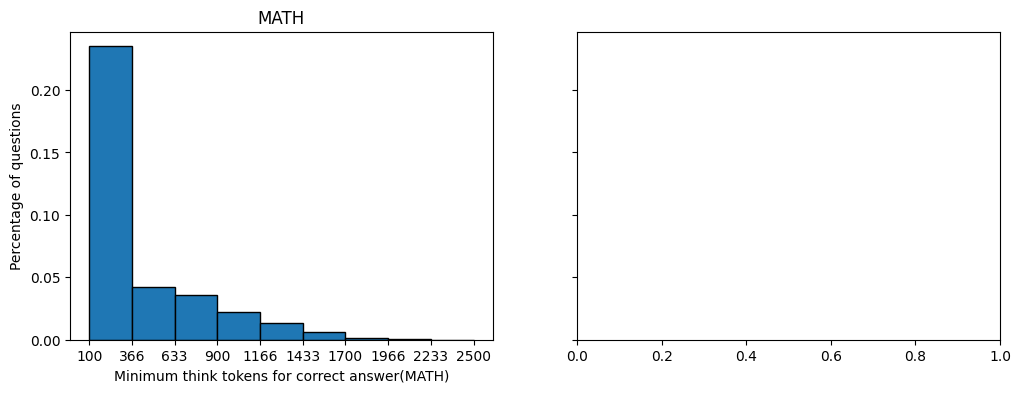

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

bins = tokens

ax[0].hist(
    min_tokens_math,
    bins=bins,
    weights=np.ones_like(min_tokens_math) / len(min_tokens_math),
    edgecolor="black"
)
ax[0].set_xticks(tokens)
ax[0].set_xlabel("Minimum think tokens for correct answer(MATH)")
ax[0].set_title("MATH")
ax[0].set_ylabel("Percentage of questions")

ax[1].hist(
    min_tokens_aime,
    bins=bins,
    weights=np.ones_like(min_tokens_aime) / len(min_tokens_aime),
    edgecolor="black",
    color="orange"
)
ax[1].set_xticks(tokens)
ax[1].set_title("AIME")
ax[1].set_xlabel("Minimum think tokens for correct answer (AIME)")

for a in ax:
    a.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.savefig("dist-correct.pdf")
plt.show()


NameError: name 'min_tokens_aime' is not defined

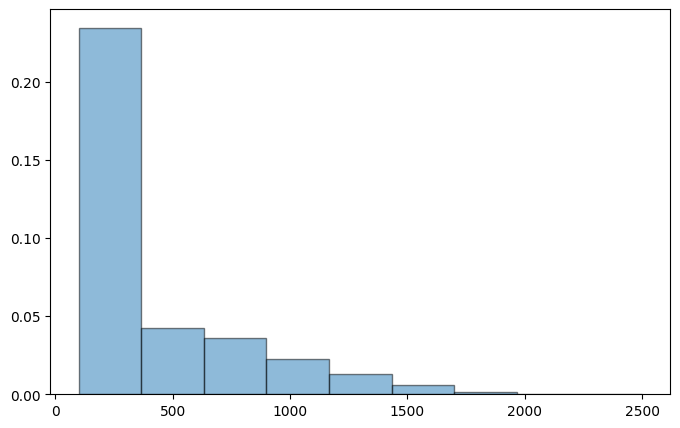

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.append(tokens - 0.5, tokens[-1] + 0.5)

ax.hist(min_tokens_math, bins=bins, weights=np.ones_like(min_tokens_math) / len(min_tokens_math),
        alpha=0.5, edgecolor="black", label="MATH")

ax.hist(min_tokens_aime, bins=bins, weights=np.ones_like(min_tokens_aime) / len(min_tokens_aime),
        alpha=0.5, edgecolor="black", label="AIME", color="orange")

ax.set_xticks(tokens)
ax.set_xlabel("Minimum think tokens (correct)")
ax.set_ylabel("Fraction of questions")
ax.legend()
ax.tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.savefig("dist-correct-overlayed.pdf")
plt.show()


NameError: name 'correct_aime' is not defined

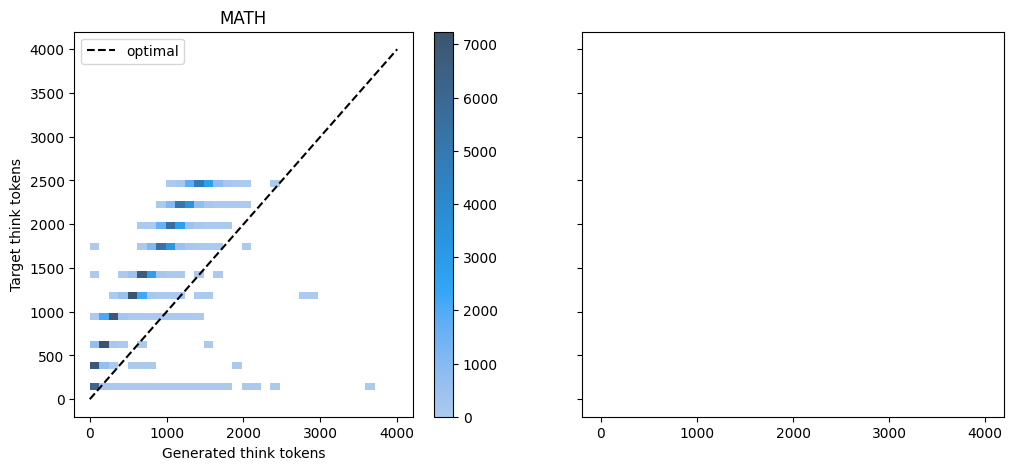

In [11]:
x = np.linspace(0, 4000, 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# MATH
sns.histplot(
    correct_math,
    x="generated_think_tokens",
    y="target_think_tokens",
    bins=30,
    pmax=0.9,
    cbar=True,
    ax=axes[0],
)
axes[0].plot(x, x, color="black", linestyle="dashed", label="optimal")
axes[0].set_title("MATH")
axes[0].set_xlabel("Generated think tokens")
axes[0].set_ylabel("Target think tokens")
axes[0].set_ylim((-200, 4200))
axes[0].legend()

# AIME
sns.histplot(
    correct_aime,
    x="generated_think_tokens",
    y="target_think_tokens",
    color="orange",
    bins=30,
    pmax=0.9,
    cbar=True,
    ax=axes[1],
)
axes[1].plot(x, x, color="black", linestyle="dashed", label="optimal")
axes[1].set_title("AIME")
axes[1].set_xlabel("Generated think tokens")
axes[1].set_ylabel("")  # shared y-axis
axes[1].set_ylim((-200, 4200))

plt.tight_layout()
plt.savefig("scatter.pdf")
plt.show()


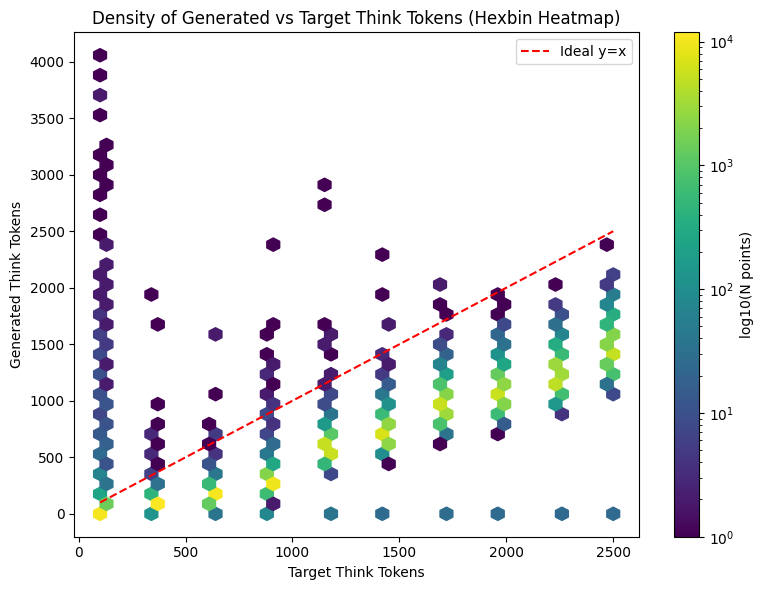

In [12]:
plt.figure(figsize=(8,6))
hb = plt.hexbin(
    df_math["target_think_tokens"],
    df_math["generated_think_tokens"],
    gridsize=40,           # number of hexes along x-axis (adjust for resolution)
    cmap="viridis",
    bins="log"             # log color scale = better for uneven densities
)
plt.colorbar(hb, label="log10(N points)")
mn, mx = df_math["target_think_tokens"].min(), df_math["target_think_tokens"].max()
plt.plot([mn, mx], [mn, mx], "r--", label="Ideal y=x")
plt.xlabel("Target Think Tokens")
plt.ylabel("Generated Think Tokens")
plt.title("Density of Generated vs Target Think Tokens (Hexbin Heatmap)")
plt.legend()
plt.tight_layout()
plt.show()
